   entry_price  stop_loss  take_profit  position_size   type  status  \
0      1.08754   1.087984     1.086208    4504.504505  Short  TP Hit   
1      1.07946   1.079730     1.078650    7851.851852  Short  SL Hit   
2      1.08339   1.083592     1.082784   10285.148515  Short  TP Hit   
3      1.08335   1.083498     1.082906   14037.837838  Short  TP Hit   
4      1.08335   1.083478     1.082966   16231.250000  Short  TP Hit   

            entry_time                  strategy    SMA_50      ATR  \
0  2024-05-28 15:30:00  Fib False Breakout Short  1.087571  0.00222   
1  2024-05-30 06:40:00  Fib False Breakout Short  1.079731  0.00100   
2  2024-05-30 22:00:00  Fib False Breakout Short  1.083641  0.00081   
3  2024-05-30 22:50:00  Fib False Breakout Short  1.083643  0.00054   
4  2024-05-30 22:50:00  Fib False Breakout Short  1.083643  0.00054   

   fib_level  fib_type      trend  mother_bar_high  mother_bar_low  \
0   1.087350        50  downtrend          1.08754         1.08713   


C:\Users\HP\AppData\Local\Temp\ipykernel_12832\3392792052.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='result', palette='pastel')


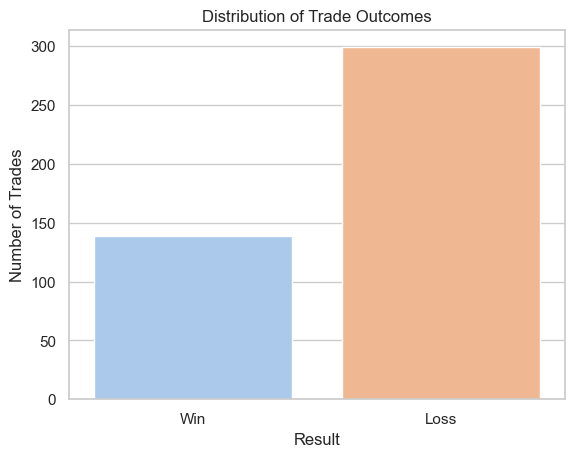

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 1: Load your dataset
df = pd.read_csv("frxEURUSD_10m_365days_trades.csv")  # <-- Replace with your actual file path

# STEP 2: Check it loaded correctly
print(df.head())

# STEP 3: Count of Wins and Losses
result_counts = df['result'].value_counts()
print("Counts:\n", result_counts)

# STEP 4: Percentage distribution
result_percent = df['result'].value_counts(normalize=True) * 100
print("\nPercentages:\n", result_percent)

# STEP 5: Plot
sns.set_theme(style="whitegrid")
sns.countplot(data=df, x='result', palette='pastel')
plt.title('Distribution of Trade Outcomes')
plt.xlabel('Result')
plt.ylabel('Number of Trades')
plt.show()


### What is the average duration of trades?

In [2]:
average_duration = df['duration'].mean()
print(f'Average trade duration: {average_duration:.2f} hours')


Average trade duration: 3.81 hours


### What is the most common strategy or setup used?

In [3]:
most_common_strategy = df['strategy'].mode()[0]
strategy_counts = df['strategy'].value_counts()

print(f"Most common strategy: {most_common_strategy}")
print("\nStrategy counts:")
print(strategy_counts)


Most common strategy: Fib False Breakout Short

Strategy counts:
strategy
Fib False Breakout Short    298
Fib False Breakout Long     140
Name: count, dtype: int64


### How many trades were TP Hit vs. SL Hit?

In [4]:
tp_hit_count = df[df['status'] == 'TP Hit'].shape[0]
sl_hit_count = df[df['status'] == 'SL Hit'].shape[0]

print(f"Number of trades where TP Hit: {tp_hit_count}")
print(f"Number of trades where SL Hit: {sl_hit_count}")


Number of trades where TP Hit: 139
Number of trades where SL Hit: 299


### What are the typical values for entry_price, stop_loss, and take_profit?

In [5]:
# Summary statistics for entry_price, stop_loss, take_profit
summary = df[['entry_price', 'stop_loss', 'take_profit']].describe()

print(summary)


       entry_price   stop_loss  take_profit
count   438.000000  438.000000   438.000000
mean      1.078739    1.078918     1.078203
std       0.030562    0.030555     0.030656
min       1.023970    1.023666     1.017466
25%       1.049907    1.050347     1.049627
50%       1.082750    1.082901     1.082164
75%       1.098302    1.099067     1.097430
max       1.140380    1.140282     1.144498


### Do trades with higher position sizes have higher win rates?

In [8]:

# Ensure correct types
df['position_size'] = pd.to_numeric(df['position_size'], errors='coerce')
df['result'] = df['result'].str.strip()  # In case of extra spaces

# Create size categories (optional: adjust bin sizes as needed)
df['size_group'] = pd.qcut(df['position_size'], q=4, labels=["Small", "Medium", "Large", "Very Large"])

# Calculate win rates for each group
win_rate_by_group = df.groupby('size_group')['result'].value_counts(normalize=True).unstack().fillna(0)
win_rate_by_group['Win Rate (%)'] = win_rate_by_group['Win'] * 100

print(win_rate_by_group[['Win Rate (%)']])


result      Win Rate (%)
size_group              
Small          41.818182
Medium         25.688073
Large          34.862385
Very Large     24.545455


C:\Users\HP\AppData\Local\Temp\ipykernel_12832\1495867593.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate_by_group = df.groupby('size_group')['result'].value_counts(normalize=True).unstack().fillna(0)


### Are certain fib levels or fib types more likely to result in a win?

In [9]:

# Clean and ensure correct types
df['result'] = df['result'].str.strip()  # Remove spaces if needed

# 1. Win rate by fib_level
fib_level_win_rate = (
    df.groupby('fib_level')['result']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)
fib_level_win_rate['Win Rate (%)'] = fib_level_win_rate['Win'] * 100

# 2. Win rate by fib_type
fib_type_win_rate = (
    df.groupby('fib_type')['result']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)
fib_type_win_rate['Win Rate (%)'] = fib_type_win_rate['Win'] * 100

# Display results
print("Win Rate by Fib Level:")
print(fib_level_win_rate[['Win Rate (%)']].sort_values(by='Win Rate (%)', ascending=False))

print("\nWin Rate by Fib Type:")
print(fib_type_win_rate[['Win Rate (%)']].sort_values(by='Win Rate (%)', ascending=False))


Win Rate by Fib Level:
result     Win Rate (%)
fib_level              
1.040365          100.0
1.080657          100.0
1.043465          100.0
1.072665          100.0
1.057772          100.0
...                 ...
1.049921            0.0
1.029815            0.0
1.029858            0.0
1.030037            0.0
1.030075            0.0

[406 rows x 1 columns]

Win Rate by Fib Type:
result    Win Rate (%)
fib_type              
618          33.532934
50           30.627306


### Does trend direction (uptrend/downtrend) affect trade outcome?


In [10]:

# Clean up whitespace just in case
df['trend'] = df['trend'].str.strip().str.lower()
df['result'] = df['result'].str.strip()

# Calculate win rate by trend
trend_win_rate = (
    df.groupby('trend')['result']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)
trend_win_rate['Win Rate (%)'] = trend_win_rate['Win'] * 100

# Show results
print(trend_win_rate[['Win Rate (%)']])


result     Win Rate (%)
trend                  
downtrend     30.201342
uptrend       35.000000


In [ ]:
### How does SMA_50 compare to entry_price in winning vs. losing trades?
What stop loss or take profit ratios lead to the most successful trades?

In [11]:

# Clean up
df['result'] = df['result'].str.strip()
df = df.dropna(subset=['entry_price', 'stop_loss', 'take_profit'])

# Calculate distances
df['sl_distance'] = abs(df['entry_price'] - df['stop_loss'])
df['tp_distance'] = abs(df['take_profit'] - df['entry_price'])

# Avoid division by zero or invalid ratios
df = df[df['sl_distance'] > 0]

# Compute risk-reward ratio
df['rr_ratio'] = df['tp_distance'] / df['sl_distance']

# Create ratio buckets
df['rr_bucket'] = pd.cut(df['rr_ratio'], bins=[0, 0.5, 1, 1.5, 2, 3, 5, 10], right=False)

# Calculate win rate per bucket
rr_win_rate = (
    df.groupby('rr_bucket')['result']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)
rr_win_rate['Win Rate (%)'] = rr_win_rate['Win'] * 100

# Display the result
print("\n✅ Win Rate by Risk-to-Reward Ratio Bucket:")
print(rr_win_rate[['Win Rate (%)']].sort_values(by='Win Rate (%)', ascending=False))



✅ Win Rate by Risk-to-Reward Ratio Bucket:
result       Win Rate (%)
rr_bucket                
[2.0, 3.0)      32.000000
[3.0, 5.0)      31.680441
[0.0, 0.5)       0.000000
[1.0, 1.5)       0.000000
[0.5, 1.0)       0.000000
[1.5, 2.0)       0.000000
[5.0, 10.0)      0.000000


C:\Users\HP\AppData\Local\Temp\ipykernel_12832\2056684541.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('rr_bucket')['result']


### Which combination of indicators (e.g., SMA_50, fib_type, ATR) results in the highest PnL?


In [12]:


# Clean up missing/extra spaces and remove incomplete rows
df['fib_type'] = df['fib_type'].astype(str).str.strip()
df.dropna(subset=['SMA_50', 'fib_type', 'ATR', 'pnl'], inplace=True)

# Optional: bucket ATR and SMA_50 for grouping (prevents too many unique values)
df['ATR_bucket'] = pd.cut(df['ATR'], bins=5)
df['SMA_bucket'] = pd.cut(df['SMA_50'], bins=5)

# Group by indicators and calculate total PnL
indicator_pnl = (
    df.groupby(['SMA_bucket', 'ATR_bucket', 'fib_type'])['pnl']
    .sum()
    .reset_index()
    .sort_values(by='pnl', ascending=False)
)

# Show top combinations
print("Top indicator combinations by total PnL:")
print(indicator_pnl.head(10))


Top indicator combinations by total PnL:
        SMA_bucket           ATR_bucket fib_type         pnl
11  (1.048, 1.071]  (0.000254, 0.00349]      618  154.945969
1   (1.024, 1.048]  (0.000254, 0.00349]      618  108.063235
30  (1.094, 1.118]  (0.000254, 0.00349]       50   93.810239
0   (1.024, 1.048]  (0.000254, 0.00349]       50   66.903132
43  (1.118, 1.141]   (0.00349, 0.00671]      618   54.294068
42  (1.118, 1.141]   (0.00349, 0.00671]       50   49.242268
10  (1.048, 1.071]  (0.000254, 0.00349]       50   43.587266
27  (1.071, 1.094]    (0.00992, 0.0131]      618   33.512297
45  (1.118, 1.141]   (0.00671, 0.00992]      618   28.908371
23  (1.071, 1.094]   (0.00349, 0.00671]      618   27.788284


C:\Users\HP\AppData\Local\Temp\ipykernel_12832\2298031617.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['SMA_bucket', 'ATR_bucket', 'fib_type'])['pnl']


### What is the optimal position size based on trade duration or volatility?


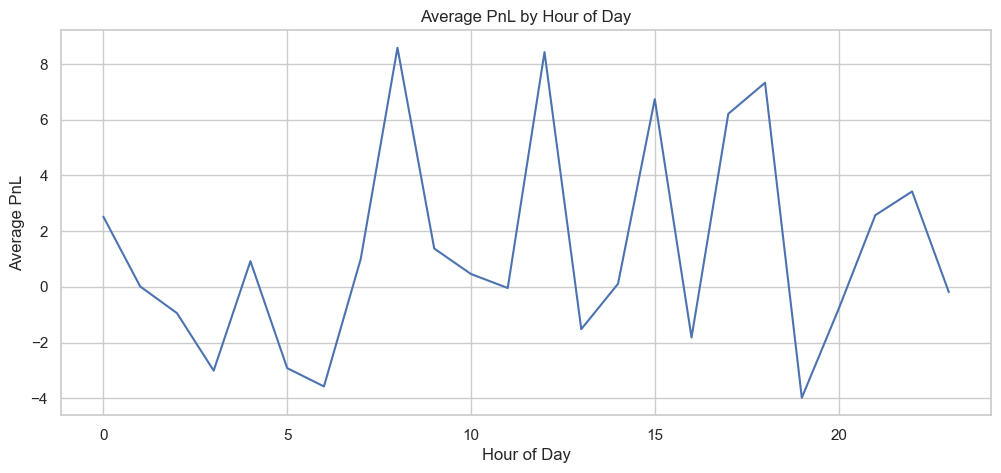

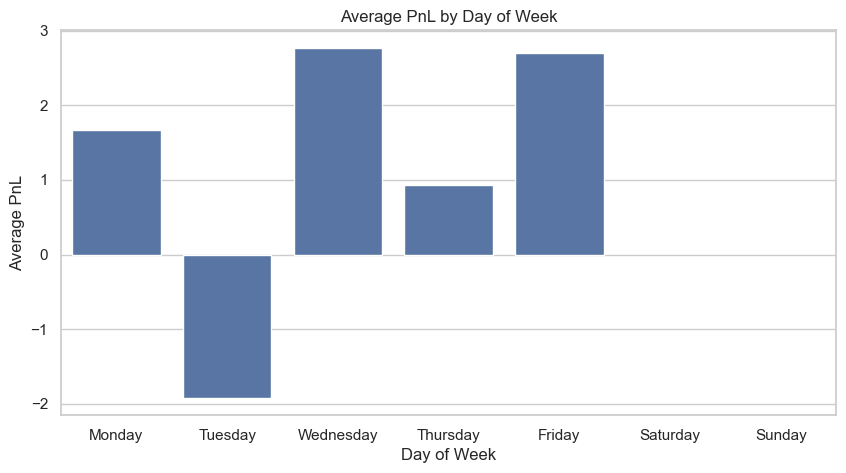

Hourly Performance:
    hour   avg_pnl  win_rate  trade_count
0      0  2.517485  0.357143           14
1      1  0.014921  0.333333           21
2      2 -0.942342  0.200000           25
3      3 -3.007072  0.192308           26
4      4  0.922402  0.285714           14
5      5 -2.917939  0.200000           15
6      6 -3.575059  0.125000           24
7      7  1.000173  0.352941           17
8      8  8.582716  0.560000           25
9      9  1.374760  0.347826           23
10    10  0.460487  0.333333           18
11    11 -0.041747  0.260870           23
12    12  8.425075  0.555556           18
13    13 -1.519302  0.230769           13
14    14  0.109905  0.277778           18
15    15  6.737525  0.421053           19
16    16 -1.817414  0.266667           15
17    17  6.210821  0.500000           14
18    18  7.326749  0.476190           21
19    19 -3.980925  0.142857           14
20    20 -0.800032  0.230769           13
21    21  2.572994  0.200000           10
22    22  3.42

In [13]:


# Assuming your DataFrame is called df and 'entry_time' is datetime type
df['entry_time'] = pd.to_datetime(df['entry_time'])

# Extract hour of day and day of week (0=Monday, 6=Sunday)
df['hour'] = df['entry_time'].dt.hour
df['day_of_week'] = df['entry_time'].dt.day_name()

# Group by hour and calculate average PnL and win rate
hourly_perf = df.groupby('hour').agg(
    avg_pnl=('pnl', 'mean'),
    win_rate=('result', lambda x: (x.str.lower() == 'win').mean()),
    trade_count=('pnl', 'count')
).reset_index()

# Group by day of week
day_perf = df.groupby('day_of_week').agg(
    avg_pnl=('pnl', 'mean'),
    win_rate=('result', lambda x: (x.str.lower() == 'win').mean()),
    trade_count=('pnl', 'count')
).reset_index()

# To sort days in weekday order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_perf['day_of_week'] = pd.Categorical(day_perf['day_of_week'], categories=days_order, ordered=True)
day_perf = day_perf.sort_values('day_of_week')

# Plot average PnL by hour
plt.figure(figsize=(12,5))
sns.lineplot(data=hourly_perf, x='hour', y='avg_pnl')
plt.title('Average PnL by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average PnL')
plt.show()

# Plot average PnL by day of week
plt.figure(figsize=(10,5))
sns.barplot(data=day_perf, x='day_of_week', y='avg_pnl')
plt.title('Average PnL by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average PnL')
plt.show()

# Optionally print tables
print("Hourly Performance:")
print(hourly_perf)

print("\nDay of Week Performance:")
print(day_perf)


### Are certain times of day or days of the week more profitable?

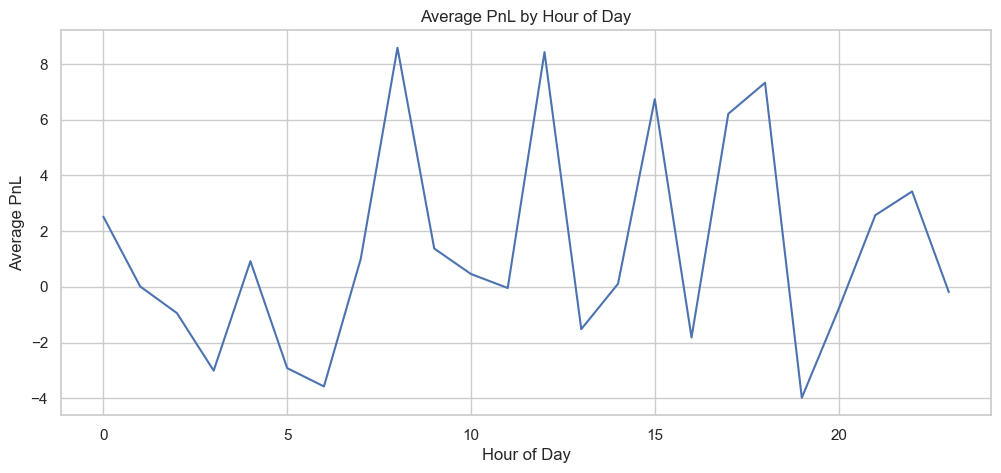

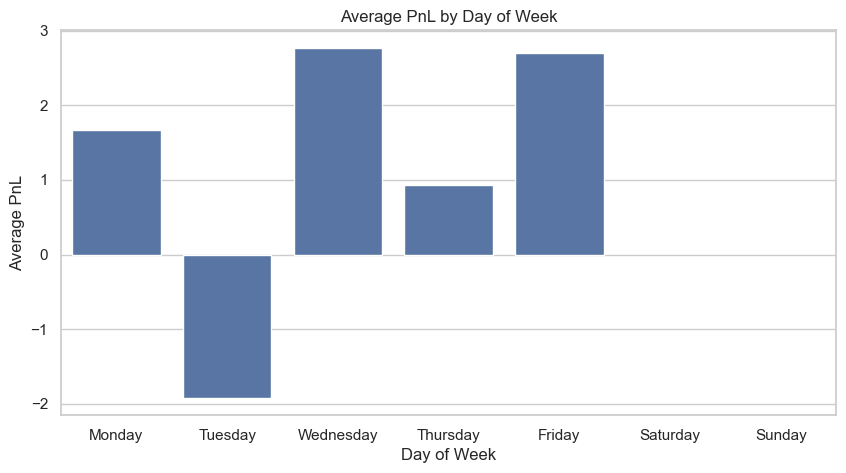

Hourly Performance:
    hour   avg_pnl  win_rate  trade_count
0      0  2.517485  0.357143           14
1      1  0.014921  0.333333           21
2      2 -0.942342  0.200000           25
3      3 -3.007072  0.192308           26
4      4  0.922402  0.285714           14
5      5 -2.917939  0.200000           15
6      6 -3.575059  0.125000           24
7      7  1.000173  0.352941           17
8      8  8.582716  0.560000           25
9      9  1.374760  0.347826           23
10    10  0.460487  0.333333           18
11    11 -0.041747  0.260870           23
12    12  8.425075  0.555556           18
13    13 -1.519302  0.230769           13
14    14  0.109905  0.277778           18
15    15  6.737525  0.421053           19
16    16 -1.817414  0.266667           15
17    17  6.210821  0.500000           14
18    18  7.326749  0.476190           21
19    19 -3.980925  0.142857           14
20    20 -0.800032  0.230769           13
21    21  2.572994  0.200000           10
22    22  3.42

In [14]:


# Assuming your DataFrame is called df and 'entry_time' is datetime type
df['entry_time'] = pd.to_datetime(df['entry_time'])

# Extract hour of day and day of week (0=Monday, 6=Sunday)
df['hour'] = df['entry_time'].dt.hour
df['day_of_week'] = df['entry_time'].dt.day_name()

# Group by hour and calculate average PnL and win rate
hourly_perf = df.groupby('hour').agg(
    avg_pnl=('pnl', 'mean'),
    win_rate=('result', lambda x: (x.str.lower() == 'win').mean()),
    trade_count=('pnl', 'count')
).reset_index()

# Group by day of week
day_perf = df.groupby('day_of_week').agg(
    avg_pnl=('pnl', 'mean'),
    win_rate=('result', lambda x: (x.str.lower() == 'win').mean()),
    trade_count=('pnl', 'count')
).reset_index()

# To sort days in weekday order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_perf['day_of_week'] = pd.Categorical(day_perf['day_of_week'], categories=days_order, ordered=True)
day_perf = day_perf.sort_values('day_of_week')

# Plot average PnL by hour
plt.figure(figsize=(12,5))
sns.lineplot(data=hourly_perf, x='hour', y='avg_pnl')
plt.title('Average PnL by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average PnL')
plt.show()

# Plot average PnL by day of week
plt.figure(figsize=(10,5))
sns.barplot(data=day_perf, x='day_of_week', y='avg_pnl')
plt.title('Average PnL by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average PnL')
plt.show()

# Optionally print tables
print("Hourly Performance:")
print(hourly_perf)

print("\nDay of Week Performance:")
print(day_perf)


### How long do winning trades typically last compared to losing ones?


In [17]:


# Clean up the 'result' column to lowercase for consistency
df['result'] = df['result'].str.strip().str.lower()

# Group by result and describe duration
duration_stats = df.groupby('result')['duration'].describe()

print("Duration stats by trade result:")
print(duration_stats)





Duration stats by trade result:
        count      mean        std  min       25%       50%       75%   max
result                                                                     
loss    299.0  3.262542  10.830154  0.0  0.166667  0.666667  1.666667  97.0
win     139.0  4.976019  11.562293  0.0  0.583333  1.833333  3.416667  66.0
